In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df1=pd.read_csv(r"cardio_train.csv",sep=";")
df1

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [5]:
df1.shape

(70000, 13)

In [6]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df1["age"]=df1["age"]/365

In [8]:
df1["age"]=df1["age"].astype(int)

In [9]:
df1["gender"].value_counts()

gender
1    45530
2    24470
Name: count, dtype: int64

In [10]:
df1["gender"]=df1["gender"].replace({1:0,2:1})# 1 for male and 0 for female

In [11]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0


In [12]:
df1.duplicated().sum()

np.int64(0)

In [13]:
df1["cholesterol"].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

<Axes: xlabel='cholesterol', ylabel='count'>

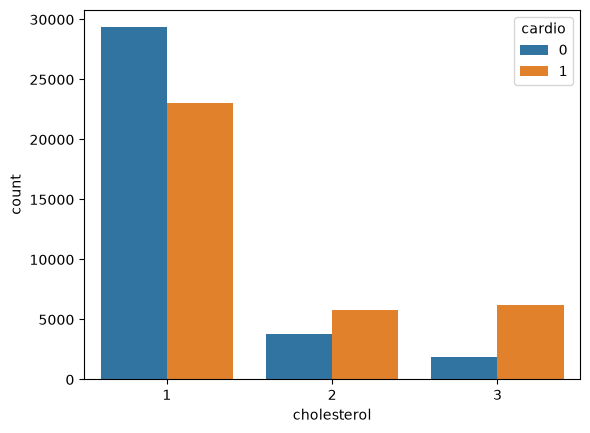

In [14]:
sns.countplot(df1,x="cholesterol",hue="cardio")

<Axes: xlabel='active', ylabel='count'>

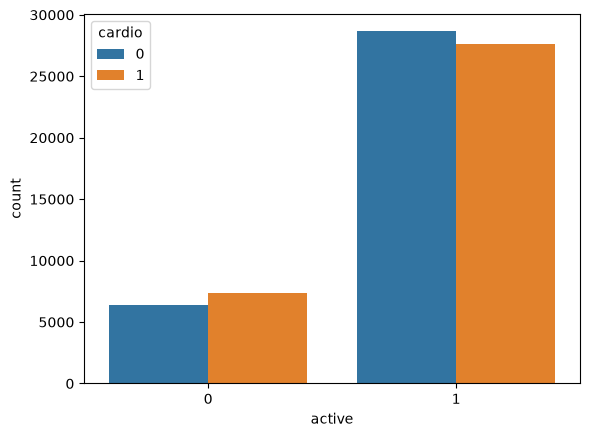

In [15]:
sns.countplot(df1,x="active",hue="cardio")

In [16]:
df1["cholesterol"].value_counts()

cholesterol
1    52385
2     9549
3     8066
Name: count, dtype: int64

In [17]:
pd.crosstab(df1["cholesterol"], df1["cardio"], normalize="index") * 100

cardio,0,1
cholesterol,,
1,55.989310,44.010690
2,39.784271,60.215729
3,23.456484,76.543516


In [18]:
pd.crosstab(df1["active"], df1["cardio"], normalize="index") * 100

cardio,0,1
active,,
0,46.422593,53.577407
1,50.910933,49.089067


In [19]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0


<Axes: xlabel='age', ylabel='Count'>

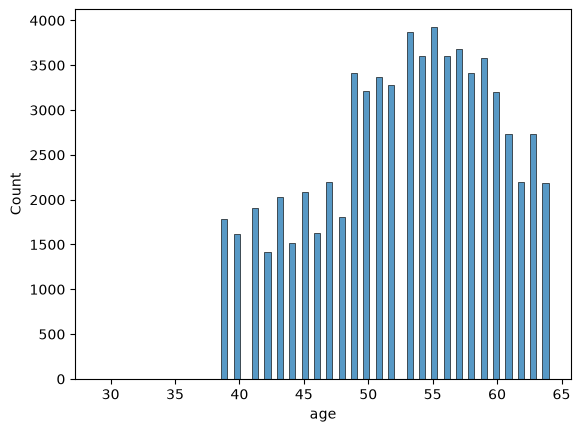

In [20]:
sns.histplot(df1,x="age")

<Axes: xlabel='ap_hi', ylabel='count'>

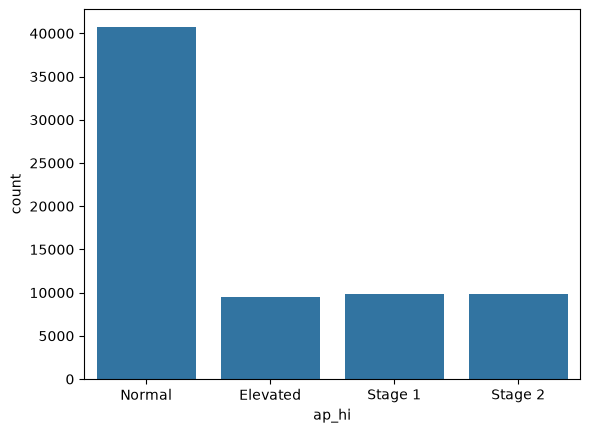

In [21]:
bins = [0, 120, 130, 140, 1000]
labels = ["Normal", "Elevated", "Stage 1", "Stage 2"]
sns.countplot(x=pd.cut(df1["ap_hi"], bins=bins, labels=labels))

In [22]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0


<Axes: xlabel='ap_lo', ylabel='count'>

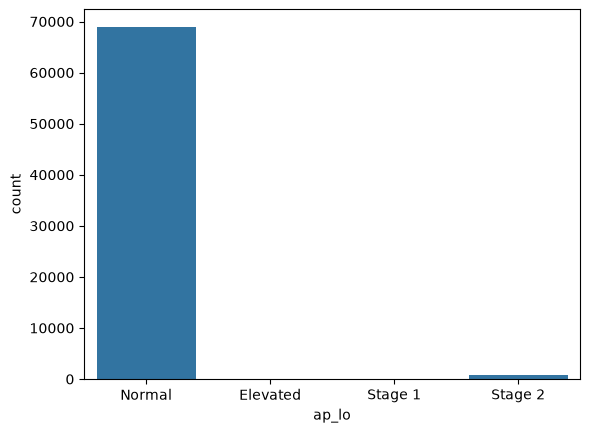

In [23]:
bins = [0, 120, 130, 140, 1000]
labels = ["Normal", "Elevated", "Stage 1", "Stage 2"]
sns.countplot(x=pd.cut(df1['ap_lo'],labels=labels,bins=bins))

<Axes: xlabel='ap_lo'>

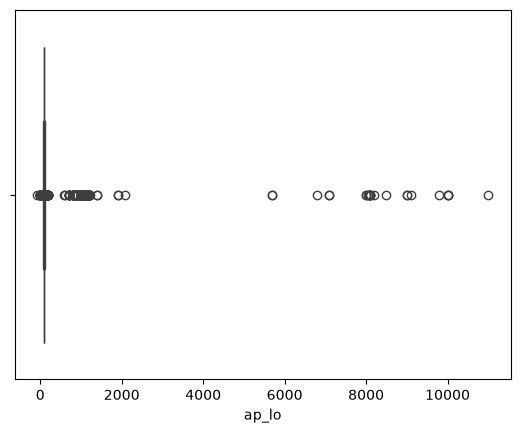

In [24]:
sns.boxplot(df1,x='ap_lo')

In [25]:
df1.drop(df1[(df1["ap_hi"]<80)|(df1["ap_hi"]>=250)].index,inplace=True)
df1.drop(df1[(df1['ap_lo']<=40)|(df1['ap_lo']>=150)].index,inplace=True)
df1 = df1[df1["ap_hi"] > df1["ap_lo"]]

<Axes: xlabel='ap_lo'>

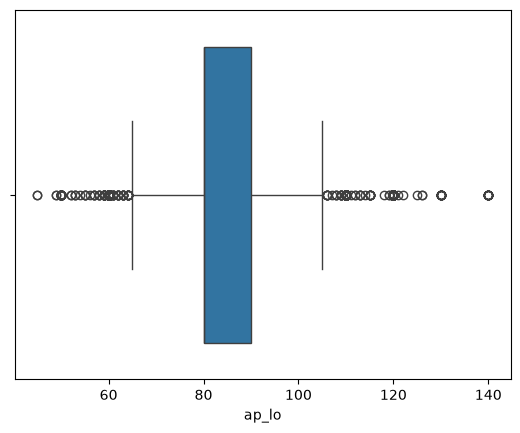

In [26]:
sns.boxplot(df1,x='ap_lo')

<Axes: xlabel='ap_hi'>

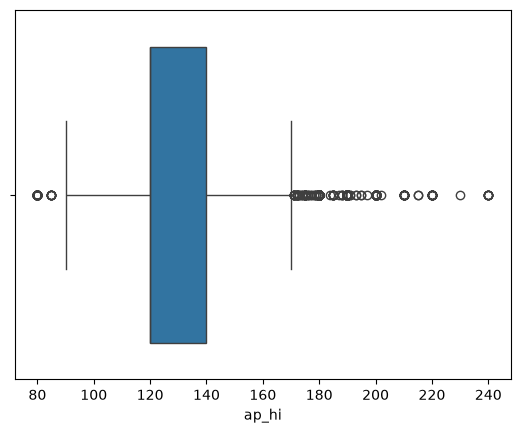

In [27]:
sns.boxplot(df1,x='ap_hi')

In [28]:
df1.shape
# A large number of rows has been removed

(68647, 13)

In [29]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50,1,168,62.0,110,80,1,1,0,0,1,0
1,1,55,0,156,85.0,140,90,3,1,0,0,1,1
2,2,51,0,165,64.0,130,70,3,1,0,0,0,1
3,3,48,1,169,82.0,150,100,1,1,0,0,1,1
4,4,47,0,156,56.0,100,60,1,1,0,0,0,0


In [30]:
#one hot encoding for cholesterol and gluc
df1['gluc'].value_counts()
df1['cholesterol'].value_counts()

cholesterol
1    51485
2     9296
3     7866
Name: count, dtype: int64

In [31]:
backup=df1.copy()

In [32]:
df1=pd.get_dummies(df1,columns=['cholesterol','gluc'],dtype=int,drop_first=True)

In [33]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3
0,0,50,1,168,62.0,110,80,0,0,1,0,0,0,0,0
1,1,55,0,156,85.0,140,90,0,0,1,1,0,1,0,0
2,2,51,0,165,64.0,130,70,0,0,0,1,0,1,0,0
3,3,48,1,169,82.0,150,100,0,0,1,1,0,0,0,0
4,4,47,0,156,56.0,100,60,0,0,0,0,0,0,0,0


In [34]:
#feature Engineering
df1['BMI']=df1["weight"]/((df1["height"]/100)**2)

In [35]:
df1.head()

,id,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
0,0,50,1,168,62.0,110,80,0,0,1,0,0,0,0,0,21.967120
1,1,55,0,156,85.0,140,90,0,0,1,1,0,1,0,0,34.927679
2,2,51,0,165,64.0,130,70,0,0,0,1,0,1,0,0,23.507805
3,3,48,1,169,82.0,150,100,0,0,1,1,0,0,0,0,28.710479
4,4,47,0,156,56.0,100,60,0,0,0,0,0,0,0,0,23.011177


In [36]:
df1.corr(numeric_only=True)["cardio"]

id               0.003841
age              0.239103
gender           0.007058
height          -0.010821
weight           0.179700
ap_hi            0.428004
ap_lo            0.341786
smoke           -0.016235
alco            -0.008685
active          -0.037524
cardio           1.000000
cholesterol_2    0.080510
cholesterol_3    0.192723
gluc_2           0.053061
gluc_3           0.070581
BMI              0.164356
Name: cardio, dtype: float64

In [37]:
mat=df1.corr(numeric_only=True)
mat

,id,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
id,1.000000,0.003935,0.003054,-0.002975,-0.002294,0.000863,-0.000623,-0.003838,0.000533,0.003524,0.003841,0.001232,0.005672,0.001265,0.001828,-0.001842
age,0.003935,1.000000,-0.023421,-0.081460,0.054362,0.208796,0.156564,-0.047627,-0.028944,-0.010320,0.239103,0.021845,0.153209,0.024795,0.093989,0.086462
gender,0.003054,-0.023421,1.000000,0.499036,0.155996,0.062172,0.067544,0.338856,0.171358,0.005932,0.007058,-0.017517,-0.029703,-0.005367,-0.020179,-0.096362
height,-0.002975,-0.081460,0.499036,1.000000,0.291630,0.018349,0.035468,0.188328,0.094711,-0.007492,-0.010821,-0.024211,-0.041016,-0.012872,-0.013921,-0.287999
weight,-0.002294,0.054362,0.155996,0.291630,1.000000,0.271121,0.254828,0.067126,0.067508,-0.017807,0.179700,0.067184,0.114236,0.094966,0.068544,0.763855
ap_hi,0.000863,0.208796,0.062172,0.018349,0.271121,1.000000,0.736100,0.028037,0.035865,-0.001351,0.428004,0.099762,0.154576,0.076232,0.064173,0.233344
ap_lo,-0.000623,0.156564,0.067544,0.035468,0.254828,0.736100,1.000000,0.025490,0.037698,-0.000669,0.341786,0.074972,0.132463,0.062954,0.049931,0.211420
smoke,-0.003838,-0.047627,0.338856,0.188328,0.067126,0.028037,0.025490,1.000000,0.340627,0.025313,-0.016235,0.024960,-0.002922,0.015862,-0.014124,-0.027818
alco,0.000533,-0.028944,0.171358,0.094711,0.067508,0.035865,0.037698,0.340627,1.000000,0.024666,-0.008685,0.038636,0.016538,0.030478,-0.003968,0.014656
active,0.003524,-0.010320,0.005932,-0.007492,-0.017807,-0.001351,-0.000669,0.025313,0.024666,1.000000,-0.037524,-0.005477,0.012161,-0.010892,-0.003013,-0.014339


In [38]:
upper=mat.where(np.triu(np.ones(mat.shape),k=1).astype(bool))
upper

,id,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
id,NaN,0.003935,0.003054,-0.002975,-0.002294,0.000863,-0.000623,-0.003838,0.000533,0.003524,0.003841,0.001232,0.005672,0.001265,0.001828,-0.001842
age,NaN,NaN,-0.023421,-0.081460,0.054362,0.208796,0.156564,-0.047627,-0.028944,-0.010320,0.239103,0.021845,0.153209,0.024795,0.093989,0.086462
gender,NaN,NaN,NaN,0.499036,0.155996,0.062172,0.067544,0.338856,0.171358,0.005932,0.007058,-0.017517,-0.029703,-0.005367,-0.020179,-0.096362
height,NaN,NaN,NaN,NaN,0.291630,0.018349,0.035468,0.188328,0.094711,-0.007492,-0.010821,-0.024211,-0.041016,-0.012872,-0.013921,-0.287999
weight,NaN,NaN,NaN,NaN,NaN,0.271121,0.254828,0.067126,0.067508,-0.017807,0.179700,0.067184,0.114236,0.094966,0.068544,0.763855
ap_hi,NaN,NaN,NaN,NaN,NaN,NaN,0.736100,0.028037,0.035865,-0.001351,0.428004,0.099762,0.154576,0.076232,0.064173,0.233344
ap_lo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.025490,0.037698,-0.000669,0.341786,0.074972,0.132463,0.062954,0.049931,0.211420
smoke,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.340627,0.025313,-0.016235,0.024960,-0.002922,0.015862,-0.014124,-0.027818
alco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.024666,-0.008685,0.038636,0.016538,0.030478,-0.003968,0.014656
active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.037524,-0.005477,0.012161,-0.010892,-0.003013,-0.014339


In [39]:
todrop=[col for col in upper if any (abs(upper[col])>0.8)]
todrop

[]

In [40]:
#todrop active,smoke,alco
# i would prefer not to drop gender as it is related with height and weight
#to increase acc will check by dropping gender and height

In [41]:
final=df1.drop(columns=['active','smoke','alco'])

In [42]:
final.drop("id",axis=1,inplace=True)

In [43]:
final.head()

,age,gender,height,weight,ap_hi,ap_lo,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
0,50,1,168,62.0,110,80,0,0,0,0,0,21.967120
1,55,0,156,85.0,140,90,1,0,1,0,0,34.927679
2,51,0,165,64.0,130,70,1,0,1,0,0,23.507805
3,48,1,169,82.0,150,100,1,0,0,0,0,28.710479
4,47,0,156,56.0,100,60,0,0,0,0,0,23.011177


In [44]:
from sklearn.model_selection import train_test_split
X=final.drop('cardio',axis=1)
y=final['cardio']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[["age",'height','weight','ap_hi','ap_lo','BMI']]=scaler.fit_transform(X_train[["age",'height','weight','ap_hi','ap_lo','BMI']])
X_test[["age",'height','weight','ap_hi','ap_lo','BMI']]=scaler.transform(X_test[["age",'height','weight','ap_hi','ap_lo','BMI']])

In [47]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [48]:
models={
    "LogisticRegression":LogisticRegression(),
    "Naive Bayes":GaussianNB(),
    "Decission Tree":DecisionTreeClassifier(),
    "K Nearest Neighbours":KNeighborsClassifier()
}
score=[]

In [49]:
for name,mod in models.items():
    mod.fit(X_train,y_train)
    y_pred=mod.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    score.append({"Name:":mod,"Accuracy:":acc,"F1_Score:":f1})
    

In [50]:
score

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.732993445010925,
  'F1_Score:': 0.7104722792607803},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.6983976693372178,
  'F1_Score:': 0.6561488001328573},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.6365622723962127,
  'F1_Score:': 0.6244166792111998},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6917698470502549,
  'F1_Score:': 0.6839432412247947}]

In [52]:
X_test.columns

Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol_2',
       'cholesterol_3', 'gluc_2', 'gluc_3', 'BMI'],
      dtype='str')

In [59]:
X_train_drop = X_train.drop(columns=["gender", "height"])
X_test_drop = X_test.drop(columns=["gender", "height"])
score2=[]

In [60]:
for name,mod in models.items():
    mod.fit(X_train_drop,y_train)
    y_pred=mod.predict(X_test_drop)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    score2.append({"Name:":mod,"Accuracy:":acc,"F1_Score:":f1})
    

In [61]:
score2

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.732993445010925,
  'F1_Score:': 0.7103350189633375},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.6983976693372178,
  'F1_Score:': 0.6561488001328573},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.6337946103423161,
  'F1_Score:': 0.6184550007588405},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6902403495994174,
  'F1_Score:': 0.6823037274968253}]

In [62]:
X_train_drop2 = X_train.drop(columns=["gender", "height",'weight'])
X_test_drop2 = X_test.drop(columns=["gender", "height",'weight'])
score3=[]

In [63]:
for name,mod in models.items():
    mod.fit(X_train_drop2,y_train)
    y_pred=mod.predict(X_test_drop2)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    score3.append({"Name:":mod,"Accuracy:":acc,"F1_Score:":f1})
    

In [64]:
score3

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.7331391114348143,
  'F1_Score:': 0.7097131991760418},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.697305171158048,
  'F1_Score:': 0.65331998665332},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.6375819373634377,
  'F1_Score:': 0.625414031918097},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6922068463219228,
  'F1_Score:': 0.6843913368185213}]

In [65]:
score

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.732993445010925,
  'F1_Score:': 0.7104722792607803},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.6983976693372178,
  'F1_Score:': 0.6561488001328573},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.6365622723962127,
  'F1_Score:': 0.6244166792111998},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6917698470502549,
  'F1_Score:': 0.6839432412247947}]

In [67]:
score2

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.732993445010925,
  'F1_Score:': 0.7103350189633375},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.6983976693372178,
  'F1_Score:': 0.6561488001328573},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.6337946103423161,
  'F1_Score:': 0.6184550007588405},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6902403495994174,
  'F1_Score:': 0.6823037274968253}]

In [68]:
df1.groupby("active")["cardio"].mean()

active
0    0.532597
1    0.485394
Name: cardio, dtype: float64

In [69]:
df1.groupby("alco")["cardio"].mean()

alco
0    0.495707
1    0.476385
Name: cardio, dtype: float64

In [70]:
df1.groupby("smoke")["cardio"].mean()

smoke
0    0.497197
1    0.468543
Name: cardio, dtype: float64

In [73]:
# Features and target
X1 = df1.drop(columns=["cardio", "gender", "height", "weight","id"])
y1 = df1["cardio"]

# Train-test split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1,
    test_size=0.2,
    random_state=42
)

# Scale the features
scaler = StandardScaler()
continuous_cols = ["age", "ap_hi", "ap_lo", "BMI"]
X_train1[continuous_cols] = scaler.fit_transform(X_train1[continuous_cols])
X_test1[continuous_cols] = scaler.transform(X_test1[continuous_cols])

In [74]:
X_train1

,age,ap_hi,ap_lo,smoke,alco,active,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
64349,1.062106,-0.701291,-0.141839,0,0,1,0,1,0,1,-0.640237
43990,0.914372,4.394738,1.986377,0,0,0,0,1,0,1,-0.020177
25973,0.766639,-0.401524,-0.141839,0,0,1,0,0,0,0,-0.593626
29059,1.505306,1.996607,1.986377,0,0,1,0,0,0,0,0.361361
4926,0.471172,0.797541,-0.141839,0,0,1,1,0,0,0,-0.758095
...,...,...,...,...,...,...,...,...,...,...,...
37932,-0.858428,-1.001057,-1.205947,0,0,0,0,0,0,0,0.822199
6399,1.062106,-0.401524,-0.141839,1,0,0,0,0,0,0,-0.727349
55965,0.766639,1.397074,1.986377,0,0,1,0,0,0,0,-0.079599
876,-1.744829,0.198008,0.922269,0,0,1,0,0,0,0,1.160623


In [76]:
score4=[]
for name,mod in models.items():
    mod.fit(X_train1,y_train1)
    y_pred=mod.predict(X_test1)
    acc=accuracy_score(y_test1,y_pred)
    f1=f1_score(y_test1,y_pred)
    score4.append({"Name:":mod,"Accuracy:":acc,"F1_Score:":f1})
    

In [77]:
score4

[{'Name:': LogisticRegression(),
  'Accuracy:': 0.7337946103423161,
  'F1_Score:': 0.7121367252106797},
 {'Name:': GaussianNB(),
  'Accuracy:': 0.6983976693372178,
  'F1_Score:': 0.6550603915035402},
 {'Name:': DecisionTreeClassifier(),
  'Accuracy:': 0.642898761835397,
  'F1_Score:': 0.6339132382587919},
 {'Name:': KNeighborsClassifier(),
  'Accuracy:': 0.6963583394027677,
  'F1_Score:': 0.6894136929151456}]

In [78]:
X_test1

,age,ap_hi,ap_lo,smoke,alco,active,cholesterol_2,cholesterol_3,gluc_2,gluc_3,BMI
11640,0.766639,0.198008,0.922269,0,0,1,0,0,0,0,1.540627
60160,0.323439,1.397074,1.986377,0,0,1,0,0,0,0,4.611856
28958,1.653039,0.198008,-1.205947,0,0,1,1,0,0,0,-0.860599
36185,1.062106,0.797541,1.986377,1,1,1,0,0,0,0,-0.297888
23171,0.618905,-0.401524,-2.270055,0,0,1,0,0,0,0,-0.443267
...,...,...,...,...,...,...,...,...,...,...,...
54462,1.653039,-0.401524,-0.141839,0,0,1,0,0,0,0,-0.552494
54715,0.766639,0.797541,-0.141839,0,0,1,0,0,0,0,-0.194664
32700,1.209839,0.198008,-0.141839,0,0,1,1,0,0,0,-0.253654
24688,0.175705,-1.001057,-1.205947,0,0,1,0,0,0,0,-0.213182


In [80]:
perfectmodel=LogisticRegression()
perfectmodel.fit(X_train1,y_train1)
y_predictfinal=perfectmodel.predict(X_test1)
acc=accuracy_score(y_test1,y_predictfinal)

In [81]:
acc

0.7337946103423161

In [82]:
import joblib

In [83]:

joblib.dump(perfectmodel, "cardio_logreg_model.pkl")
joblib.dump(scaler, "cardio_scaler.pkl")
joblib.dump(list(X1.columns), "cardio_feature_order.pkl")
print("Saved model, scaler, and feature order")

Saved model, scaler, and feature order
